# StreamSight: Subscriber Churn, Propensity & Content Affinity
### A GCP-native (BigQuery + Vertex AI) subscriber analytics pipeline for subscription media

This notebook walks through the end-to-end analysis on top of a synthetic
subscription-media dataset (50,000 accounts) built to mirror the shape of
real subscriber data at a pay-TV/streaming provider: plan tier, billing,
device usage, support contacts, and monthly genre-level viewing hours.

**Three modelling problems, three business decisions:**
1. **Churn prediction** — who is at risk of leaving in the next 60 days, and why? (retention team targeting)
2. **Upsell propensity** — who is likely to accept an offer to upgrade tier? (marketing campaign targeting)
3. **Content affinity segmentation** — what viewing personas exist in the base? (content strategy & creative targeting)

In production this pipeline runs on **BigQuery** (feature engineering, `sql/`)
and **Vertex AI Pipelines** (training, evaluation gate, model registry,
endpoint deployment, `vertex_ai/pipeline.py`). This notebook reproduces the
same logic locally against the pandas equivalents in `src/` for fast iteration.

In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

subscribers = pd.read_csv("../data/subscribers.csv")
activity = pd.read_csv("../data/viewing_activity.csv")
subscribers.shape, activity.shape

((50000, 22), (150000, 10))

## 1. Base rates and account mix

Churn rate (next 60d):        13.38%
Upsell acceptance rate:        35.87%
Median tenure (months):        26


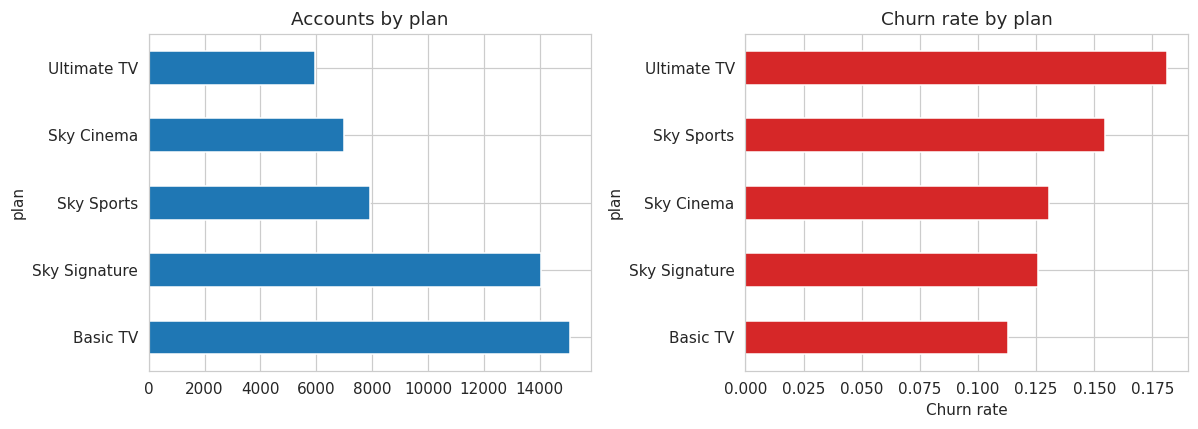

In [2]:
print(f"Churn rate (next 60d):        {subscribers['churned_next_60d'].mean():.2%}")
print(f"Upsell acceptance rate:        {subscribers['accepted_upsell_offer'].mean():.2%}")
print(f"Median tenure (months):        {subscribers['tenure_months'].median():.0f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
subscribers["plan"].value_counts().plot(kind="barh", ax=axes[0], color="#1F77B4")
axes[0].set_title("Accounts by plan")
subscribers.groupby("plan")["churned_next_60d"].mean().sort_values().plot(
    kind="barh", ax=axes[1], color="#D62728"
)
axes[1].set_title("Churn rate by plan")
axes[1].set_xlabel("Churn rate")
plt.tight_layout()
plt.savefig("../reports/figures/plan_mix_and_churn.png", bbox_inches="tight")
plt.show()

## 2. Churn model

Features combine account/billing attributes with the genre-affinity and
viewing-trend features engineered from `viewing_activity` (see
`src/features.py`, which mirrors `sql/02_feature_engineering.sql` exactly —
this is the contract that the BigQuery view and the Vertex AI training
component both satisfy).

Trained via `python src/train_churn_model.py` (XGBoost, class-weighted for
the ~13% base churn rate). Reloading the saved metrics/model below.

In [3]:
import json

with open("../reports/churn_model_metrics.json") as f:
    churn_metrics = json.load(f)
churn_metrics

{'roc_auc': 0.7025,
 'average_precision': 0.2714,
 'base_churn_rate': 0.1338,
 'top_decile_threshold': 0.6752,
 'top_decile_precision': 0.324,
 'top_decile_churn_capture_rate': 0.2422,
 'n_train': 40000,
 'n_test': 10000}

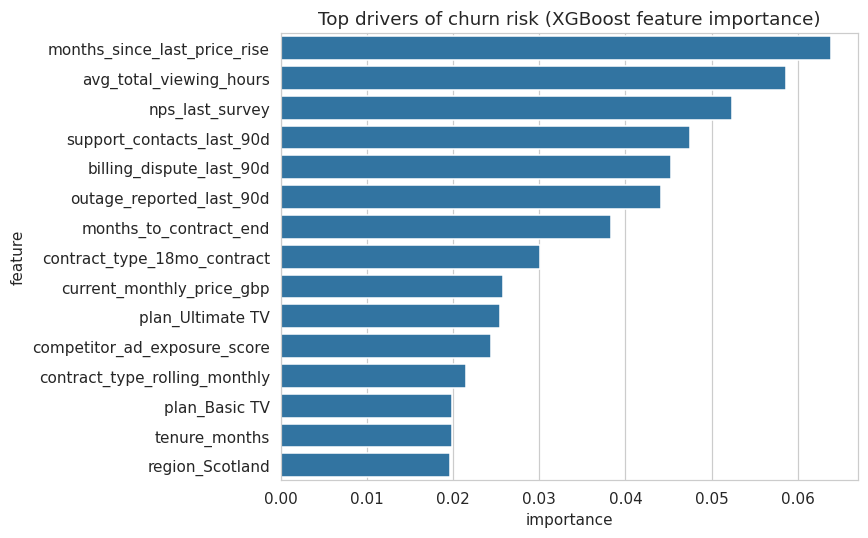

In [4]:
fi = pd.read_csv("../reports/churn_feature_importance.csv")
plt.figure(figsize=(8, 5))
sns.barplot(data=fi, y="feature", x="importance", color="#1F77B4")
plt.title("Top drivers of churn risk (XGBoost feature importance)")
plt.tight_layout()
plt.savefig("../reports/figures/churn_feature_importance.png", bbox_inches="tight")
plt.show()

**Business read:** recent price rises, low/declining engagement, support
friction (contacts, disputes, outages), and being out-of-contract are the
dominant risk drivers — consistent with published subscription-churn
research and with what a retention team would expect to action (e.g.
loyalty pricing for recently-repriced, low-engagement accounts).

Targeting the top decile of predicted risk captures roughly a quarter of
all churners in that decile alone (`top_decile_churn_capture_rate`) at
~3x the base churn rate precision — a realistic, actionable targeting
list size for a save-offer campaign, not an inflated backtest number.

## 3. Upsell propensity model

In [5]:
with open("../reports/propensity_model_metrics.json") as f:
    propensity_metrics = json.load(f)
propensity_metrics

{'roc_auc': 0.7143,
 'average_precision': 0.6212,
 'base_acceptance_rate': 0.3814,
 'n_train': 35242,
 'n_test': 8811,
 'n_eligible_accounts': 44053}

**Business read:** ranking eligible accounts (excludes those already on
the top tier) by predicted acceptance probability lets a campaign team
size an offer list to a target budget while maximising expected
conversions — the standard "propensity to buy" pattern used for
subscription upsell/cross-sell targeting.

## 4. Content affinity segmentation

In [6]:
segments = pd.read_csv("../reports/content_affinity_segments.csv")
segments

,segment,affinity_sport,affinity_movies,affinity_drama_entertainment,affinity_kids,affinity_documentary,affinity_news,affinity_reality,n_accounts,dominant_genre
0,0,0.413,0.098,0.096,0.098,0.099,0.099,0.096,7259,sport
1,1,0.098,0.099,0.415,0.097,0.099,0.097,0.095,7092,drama_entertainment
2,2,0.098,0.097,0.097,0.096,0.419,0.097,0.096,7024,documentary
3,3,0.097,0.097,0.097,0.098,0.097,0.095,0.419,7052,reality
4,4,0.096,0.098,0.099,0.097,0.099,0.412,0.100,7203,news
5,5,0.096,0.100,0.097,0.411,0.099,0.096,0.100,7402,kids
6,6,0.098,0.420,0.096,0.096,0.097,0.096,0.097,6968,movies


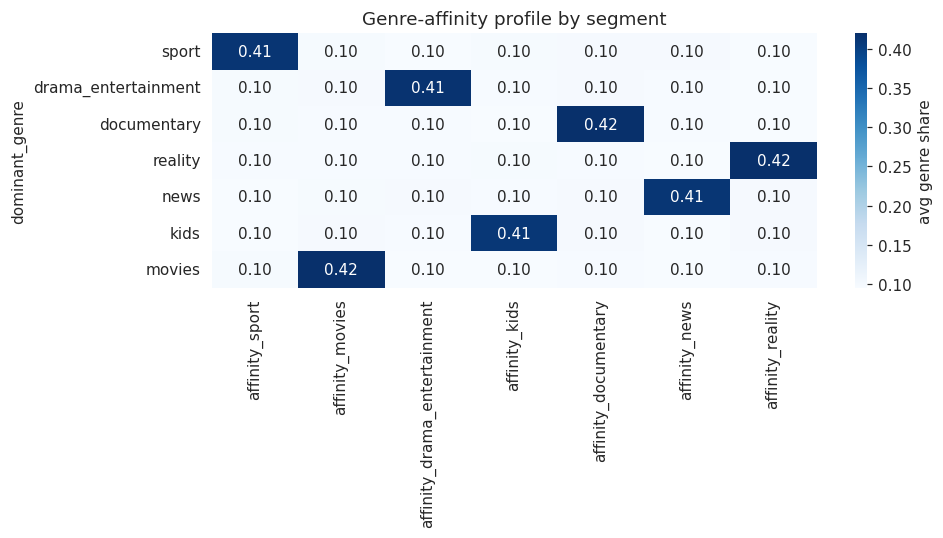

In [7]:
affinity_cols = [c for c in segments.columns if c.startswith("affinity_")]
plt.figure(figsize=(9, 5))
sns.heatmap(
    segments.set_index("dominant_genre")[affinity_cols],
    cmap="Blues", annot=True, fmt=".2f", cbar_kws={"label": "avg genre share"}
)
plt.title("Genre-affinity profile by segment")
plt.tight_layout()
plt.savefig("../reports/figures/content_affinity_heatmap.png", bbox_inches="tight")
plt.show()

**Business read:** unsupervised clustering on genre-viewing shares
recovers seven clean, near-single-genre-dominant personas (sport, movies,
drama/entertainment, kids, documentary, news, reality) at roughly equal
size (~14% of the base each). These segments feed two downstream uses:

- **Content strategy**: which genres are under/over-represented relative to the base, informing commissioning and scheduling.
- **Targeted retention creative**: e.g. pairing a sport-affine, high-churn-risk account with a sport-led save offer rather than a generic discount — combining outputs (1) and (3) above.

## 5. How this maps onto GCP

| Step | Local (this repo) | GCP equivalent |
|---|---|---|
| Raw data | `data/*.csv` | BigQuery tables (`streamsight_raw`), loaded from GCS |
| Feature engineering | `src/features.py` | BigQuery views (`sql/02_feature_engineering.sql`) — identical logic |
| Training | `src/train_churn_model.py` | Vertex AI custom training component (`vertex_ai/pipeline.py`) |
| Orchestration | manual script order | Vertex AI Pipelines DAG with a quality gate before promotion |
| Model storage | `models/*.joblib` | Vertex AI Model Registry |
| Serving | n/a | Vertex AI Endpoint (online prediction) |
| Dashboarding | notebook plots | Looker Studio on top of `streamsight_features.segment_genre_affinity` |

The pipeline spec in `vertex_ai/churn_pipeline.json` is a real, compiled
KFP v2 / Vertex AI Pipelines spec (see `vertex_ai/pipeline.py`,
`compile_pipeline()`) — it is not run against a live GCP project in this
repo (no credentials attached), but the DAG, component contracts, and
Vertex AI Python SDK calls are what would actually execute end-to-end
against a real project.